# 24 — GCD model on GLOBE: GradCAM-guided cropping
For each GLOBE image:
1. Run the GCD model on the full resized image
2. Generate a GradCAM heatmap for the predicted class
3. Crop the original image to the activated region
4. Re-classify the tight crop

GradCAM requires one backward pass per image — `MAX_PER_CLASS=600` keeps runtime reasonable on CPU (~30–60 min). Increase for a fuller evaluation.

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as tvm
import torchvision.transforms.v2 as T
from torchvision.transforms.v2 import InterpolationMode
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm

In [28]:
GLOBE_ROOT    = Path('../resources/cloud-images/NASA_GLOBE_CD/extract_filtered-thr99-sam3000')
GCD_CKPT      = Path('../models/best_cloudensenet_15_2.pt')
MAX_PER_CLASS = 600   # raise to 3000 for a full evaluation (much slower on CPU)
BATCH_SIZE    = 64
CAM_THRESHOLD = 0.5   # fraction of peak activation used to define the bounding box
CAM_PAD_FRAC  = 0.1   # padding added around the activated region
device        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

GLOBE_TO_GCD = {
    'Ac': '2_altocumulus',
    'Cb': '6_cumulonimbus',
    'Ci': '3_cirrus',
    'Cu': '1_cumulus',
    'Sc': '5_stratocumulus',
}
class_names  = sorted(GLOBE_TO_GCD.values())
label_to_idx = {c: i for i, c in enumerate(class_names)}

device: cpu


In [29]:
eval_tf = T.Compose([
    T.Resize((224, 224), interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [30]:
class TopBlock(nn.Module):
    def __init__(self, in_features, n_classes, hidden_dim=512, dropout=0.5):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(p=dropout),
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(p=dropout / 2),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x):
        return self.block(x)


model            = tvm.densenet121(weights=None).to(device)
model.classifier = TopBlock(in_features=1024, n_classes=5).to(device)
model.load_state_dict(torch.load(GCD_CKPT, map_location=device, weights_only=True))
model.eval()
print(f'GCD model loaded from {GCD_CKPT}')

GCD model loaded from ../models/best_cloudensenet_15_2.pt


In [31]:
class GradCAM:
    """GradCAM on DenseNet121 (features.norm5).

    DenseNet's forward applies F.relu(features, inplace=True) on norm5's output,
    which is incompatible with retain_grad() regardless of which layer is hooked.
    We patch the model's forward to use inplace=False while GradCAM is active,
    then restore the original on remove().
    """

    def __init__(self, model):
        self.model        = model
        self._activation  = None
        self._orig_forward = model.forward

        def _patched(x):
            features = model.features(x)
            out = F.relu(features, inplace=False)
            out = F.adaptive_avg_pool2d(out, (1, 1))
            out = torch.flatten(out, 1)
            return model.classifier(out)

        model.forward = _patched
        self._fwd = model.features.norm5.register_forward_hook(self._save_act)

    def _save_act(self, module, inp, out):
        self._activation = out
        if out.requires_grad:
            out.retain_grad()

    def __call__(self, x):
        self.model.zero_grad()
        out = self.model(x)
        cls = out.argmax(dim=1).item()
        out[0, cls].backward()

        grads   = self._activation.grad          # (1, 1024, 7, 7)
        weights = grads.mean(dim=[2, 3], keepdim=True)
        cam     = F.relu((weights * self._activation).sum(dim=1)).squeeze(0)
        cam     = cam.detach().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam, cls

    def remove(self):
        self._fwd.remove()
        self.model.forward = self._orig_forward


def heatmap_to_bbox(cam, img_w, img_h, threshold=CAM_THRESHOLD, pad_frac=CAM_PAD_FRAC):
    """Upsample GradCAM to image dims and return bounding box of activated region.
    Returns (x0, y0, x1, y1) in image coordinates, or None to use full image."""
    if cam.max() == 0:
        return None
    t  = torch.from_numpy(cam).unsqueeze(0).unsqueeze(0)
    up = F.interpolate(t, size=(img_h, img_w), mode='bilinear', align_corners=False)
    up = up.squeeze().numpy()

    binary = up >= (threshold * up.max())
    if not binary.any():
        return None

    rows = np.where(binary.any(axis=1))[0]
    cols = np.where(binary.any(axis=0))[0]
    y0, y1 = int(rows[0]),  int(rows[-1])
    x0, x1 = int(cols[0]),  int(cols[-1])

    pad_y = max(1, int((y1 - y0) * pad_frac))
    pad_x = max(1, int((x1 - x0) * pad_frac))
    return (max(0, x0 - pad_x), max(0, y0 - pad_y),
            min(img_w, x1 + pad_x), min(img_h, y1 + pad_y))


print('GradCAM and helpers defined')

GradCAM and helpers defined


In [32]:
all_paths, all_labels = [], []
for globe_cls, gcd_cls in GLOBE_TO_GCD.items():
    cls_dir = GLOBE_ROOT / globe_cls
    label   = label_to_idx[gcd_cls]
    imgs    = sorted(p for p in cls_dir.iterdir()
                     if p.suffix.lower() in {'.jpg', '.jpeg', '.png'})[:MAX_PER_CLASS]
    all_paths.extend(imgs)
    all_labels.extend([label] * len(imgs))
    print(f'{globe_cls} → {gcd_cls}: {len(imgs):,} images')

print(f'\nTotal: {len(all_paths):,} images')

Ac → 2_altocumulus: 600 images
Cb → 6_cumulonimbus: 600 images
Ci → 3_cirrus: 600 images
Cu → 1_cumulus: 600 images
Sc → 5_stratocumulus: 600 images

Total: 3,000 images


In [33]:
gradcam    = GradCAM(model)
all_preds  = []
all_targets = []
fallbacks  = 0

for path, label in tqdm(zip(all_paths, all_labels), total=len(all_paths), desc='GradCAM + reclassify'):
    img_orig = Image.open(path).convert('RGB')
    W, H     = img_orig.size

    # Pass 1: full image → GradCAM
    x       = eval_tf(img_orig).unsqueeze(0).to(device)
    cam, _  = gradcam(x)

    # Crop to activated region
    bbox = heatmap_to_bbox(cam, W, H)
    if bbox is not None:
        img_crop = img_orig.crop(bbox)
    else:
        img_crop = img_orig
        fallbacks += 1

    # Pass 2: classify the tight crop (no gradient needed)
    x2 = eval_tf(img_crop).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = torch.argmax(model(x2), dim=1).item()

    all_preds.append(pred)
    all_targets.append(label)

gradcam.remove()
correct = sum(p == t for p, t in zip(all_preds, all_targets))
print(f'Overall accuracy: {correct}/{len(all_targets)} = {correct/len(all_targets):.4f}')
print(f'Full-image fallbacks: {fallbacks}/{len(all_targets)}')

GradCAM + reclassify: 100%|██████████| 3000/3000 [09:23<00:00,  5.32it/s]  

Overall accuracy: 1098/3000 = 0.3660
Full-image fallbacks: 0/3000


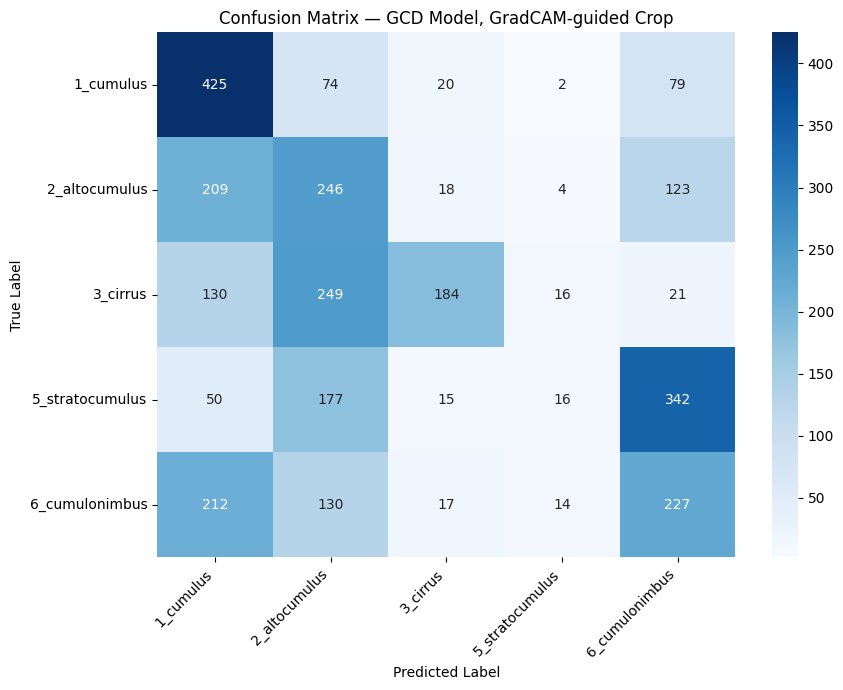

In [36]:
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — GCD Model, GradCAM-guided Crop')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../confusion matrix GCD gradcam crop.png', dpi=150)
plt.show()

In [37]:
print(classification_report(all_targets, all_preds, target_names=class_names, digits=3))

                 precision    recall  f1-score   support

      1_cumulus      0.414     0.708     0.523       600
  2_altocumulus      0.281     0.410     0.333       600
       3_cirrus      0.724     0.307     0.431       600
5_stratocumulus      0.308     0.027     0.049       600
 6_cumulonimbus      0.287     0.378     0.326       600

       accuracy                          0.366      3000
      macro avg      0.403     0.366     0.332      3000
   weighted avg      0.403     0.366     0.332      3000

